# HEADER
**Name:** CCL_SpatialData_ARIA_03.ipynb  
**Project:** low dose ARIA (Akhil's project)  
**Purpose:**  
    - 01. create SpatialData object from Xenium output folders and format tables (anndata) with Seurat metadata  
    - 02. spatial neighborhood analysis of Xenium Spatial Transcriptomics data  
    - 03. Use SpatialData to visualize cells near CAA  
**Input Files:** xenium output folders  
**Output Files:** merged spatialdata zarr  
**Conda env:** scverse_env  
**Python kernel:** Python (scverse_env)  
**Date created:** 03/11/26  
**Last updated:** 03/11/26  
**Author:** Chloe Lucido  


## 00. Importing libraries and modules

In [1]:
import spatialdata as sd
from spatialdata_io import xenium
from spatialdata.models import Image2DModel
from spatialdata import concatenate
from spatialdata import sanitize_table
from spatialdata.models import TableModel
from spatialdata.models import ShapesModel
from spatialdata.transformations import Identity
from spatialdata.transformations import get_transformation
import spatialdata_plot



import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

import pandas as pd
import geopandas as gpd
from shapely.geometry import box
from shapely.geometry import Point
from sklearn.neighbors import NearestNeighbors

import numpy as np
import tifffile as tiff
import openpyxl
import anndata as ad

pd.set_option("future.infer_string", False)
pd.options.mode.string_storage = "python"


ad.settings.allow_write_nullable_strings = True

**IMPORTANT**
- rename .xenium files to "experiment.xenium" so that spatialdata can identify and read them
- can do this using commandline (ex: mv experiment_slide1.xenium experiment.xenium)
IN THE FUTURE (after ARIA project), define a function that can read these multi-slide outputs without having to rename the files


## 01. Creating SpatialData objs

In [2]:
## File Paths

# path to slide 1 xenium output folder
xenium_path1 = "/Users/cclu223/Desktop/Xenium_ST_Analysis/Aging_Metabolism_Runs/Run2_20250606__202944__20250606_AgingXMetabolism_2/Slide1_output-XETG00118__0021991__Region_1__20250606__202953/"

# path to slide 2 xenium output folder 
xenium_path2 = "/Users/cclu223/Desktop/Xenium_ST_Analysis/Aging_Metabolism_Runs/Run2_20250606__202944__20250606_AgingXMetabolism_2/Slide2_output-XETG00118__0021998__Region_1__20250606__202953/"

# output path
zarr_path = "/Users/cclu223/Desktop/Xenium_ST_Analysis/Aging_Metabolism_Runs/ARIA_Analysis/Squidpy_output"

In [3]:
## creating spatialdata objects

sdata1 = xenium(xenium_path1, cells_as_circles = True)

sdata2 = xenium(xenium_path2, cells_as_circles = True)


/Users/cclu223/miniconda3/envs/scverse_env/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              


/Users/cclu223/miniconda3/envs/scverse_env/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              


In [4]:
# inspect spatial data objs
print("sdata1: \n", sdata1, "\n")
print("sdata2: \n", sdata2)

sdata1: 
 SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (1, 112094, 53994), (1, 56047, 26997), (1, 28023, 13498), (1, 14011, 6749), (1, 7005, 3374)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (112094, 53994), (56047, 26997), (28023, 13498), (14011, 6749), (7005, 3374)
│     └── 'nucleus_labels': DataTree[yx] (112094, 53994), (56047, 26997), (28023, 13498), (14011, 6749), (7005, 3374)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (413608, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (413608, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (413608, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (413608, 480)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nuc

## 02. Adding co-registered THIO-S images to SpatialData objs

In [5]:
# adapted from Kai Saito

# SLIDE 1

# read in coregistered ThioS image
path_1 = "/Users/cclu223/Desktop/Xenium_ST_Analysis/Aging_Metabolism_Runs/ARIA_Analysis/Images/20260107_PYR_slide0021991_ThioS_coregistered.ome.tif"

with tiff.TiffFile(path_1) as tif:
    baseimage = tif.series[0].asarray()

# add channel dimension
exp_image = np.expand_dims(baseimage, axis=2)

# parse it 
parsed_ThioS = Image2DModel.parse(exp_image, dims=("y", "x", "c"))

# now passes validation (=can be placed inside a SpatialData object)
Image2DModel().validate(parsed_ThioS)

# add in images to sdata
sdata1.images["ThioS"] = parsed_ThioS

# SANITY CHECK
print("sdata1: \n", sdata1)


# SLIDE 2

# read in coregistered ThioS image
path_2 = "/Users/cclu223/Desktop/Xenium_ST_Analysis/Aging_Metabolism_Runs/ARIA_Analysis/Images/20260122-corregistration_slide2_thios_LZWpyr.ome.tif"

with tiff.TiffFile(path_2) as tif:
    baseimage = tif.series[0].asarray()

# add channel dimension
exp_image = np.expand_dims(baseimage, axis=2)

# parse it 
parsed_ThioS = Image2DModel.parse(exp_image, dims=("y", "x", "c"))

# now passes validation (=can be placed inside a SpatialData object)
Image2DModel().validate(parsed_ThioS)

# add in images to sdata
sdata2.images["ThioS"] = parsed_ThioS

# SANITY CHECK
print("sdata2: \n", sdata2)

sdata1: 
 SpatialData object
├── Images
│     ├── 'ThioS': DataArray[cyx] (1, 112094, 53994)
│     └── 'morphology_focus': DataTree[cyx] (1, 112094, 53994), (1, 56047, 26997), (1, 28023, 13498), (1, 14011, 6749), (1, 7005, 3374)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (112094, 53994), (56047, 26997), (28023, 13498), (14011, 6749), (7005, 3374)
│     └── 'nucleus_labels': DataTree[yx] (112094, 53994), (56047, 26997), (28023, 13498), (14011, 6749), (7005, 3374)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (413608, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (413608, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (413608, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (413608, 480)
with coordinate systems:
    ▸ 'global', with elements:
        ThioS (Images), morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), trans

## 03. SUBSET SHAPES

### 03a. read in adatas v2 and attach to sdatas

In [6]:
# read in adatas
adata1 = ad.read_h5ad("/Users/cclu223/Desktop/Xenium_ST_Analysis/Aging_Metabolism_Runs/ARIA_Analysis/Squidpy/slide1_adata_v2.h5ad")
adata2 = ad.read_h5ad("/Users/cclu223/Desktop/Xenium_ST_Analysis/Aging_Metabolism_Runs/ARIA_Analysis/Squidpy/slide2_adata_v2.h5ad")

# add to sdata objs
sdata1["table"] = adata1
sdata2["table"] = adata2

### 03b. SLIDE 1

In [7]:
# extract shapes from sdata obj
shapes1 = sdata1.shapes

# add slide prefixes to cell id (cell ids stored in index)
shapes1["cell_boundaries"].index = "slide1_" + shapes1["cell_boundaries"].index.astype(str)
shapes1["cell_circles"].index = "slide1_" + shapes1["cell_circles"].index.astype(str)
shapes1["nucleus_boundaries"].index = "slide1_" + shapes1["nucleus_boundaries"].index.astype(str)


In [8]:
# SANITY CHECK
shapes1["cell_boundaries"].index

Index(['slide1_aaaabjgj-1', 'slide1_aaaaeked-1', 'slide1_aaaajpbk-1',
       'slide1_aaaanopd-1', 'slide1_aaaaohne-1', 'slide1_aaaapgcp-1',
       'slide1_aaabblpi-1', 'slide1_aaabcndj-1', 'slide1_aaabeghn-1',
       'slide1_aaabehii-1',
       ...
       'slide1_oiknmdpk-1', 'slide1_oiknncki-1', 'slide1_oiknndfg-1',
       'slide1_oiknndhd-1', 'slide1_oiknneok-1', 'slide1_oikoaolo-1',
       'slide1_oikodkhp-1', 'slide1_oikofmep-1', 'slide1_oikogkcf-1',
       'slide1_oikoiopc-1'],
      dtype='object', length=413608)

In [9]:
# make sure that the cell ids match 
len(set(adata1.obs_names).intersection(set(shapes1["cell_boundaries"].index))) # output should be same as number of obs


173073

In [10]:
# extract cell IDs from processed adata obj
cells_keep = adata1.obs_names

shapes1_subset = {}

# subset shapes 
shapes1_subset["cell_boundaries"] = shapes1["cell_boundaries"].loc[cells_keep]
shapes1_subset["cell_circles"] = shapes1["cell_circles"].loc[cells_keep]
shapes1_subset["nucleus_boundaries"] = shapes1["nucleus_boundaries"].loc[cells_keep]

In [11]:
# ensure that it was subset 
len(shapes1_subset["nucleus_boundaries"].index)

173073

In [12]:
# put shapes back into sdata
for key in shapes1_subset:
    sdata1.shapes[key] = shapes1_subset[key]

In [13]:
# SANITY CHECK
sdata1

SpatialData object
├── Images
│     ├── 'ThioS': DataArray[cyx] (1, 112094, 53994)
│     └── 'morphology_focus': DataTree[cyx] (1, 112094, 53994), (1, 56047, 26997), (1, 28023, 13498), (1, 14011, 6749), (1, 7005, 3374)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (112094, 53994), (56047, 26997), (28023, 13498), (14011, 6749), (7005, 3374)
│     └── 'nucleus_labels': DataTree[yx] (112094, 53994), (56047, 26997), (28023, 13498), (14011, 6749), (7005, 3374)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (173073, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (173073, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (173073, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (173073, 480)
with coordinate systems:
    ▸ 'global', with elements:
        ThioS (Images), morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Po

### 03c. SLIDE 2

In [14]:
# extract shapes from sdata obj
shapes2 = sdata2.shapes

# add slide prefixes to cell id (cell ids stored in index)
shapes2["cell_boundaries"].index = "slide2_" + shapes2["cell_boundaries"].index.astype(str)
shapes2["cell_circles"].index = "slide2_" + shapes2["cell_circles"].index.astype(str)
shapes2["nucleus_boundaries"].index = "slide2_" + shapes2["nucleus_boundaries"].index.astype(str)

In [15]:
# SANITY CHECK
shapes2["cell_boundaries"].index

Index(['slide2_aaaaaibp-1', 'slide2_aaabcndb-1', 'slide2_aaabfjhg-1',
       'slide2_aaabkpli-1', 'slide2_aaabmkkd-1', 'slide2_aaabpbja-1',
       'slide2_aaacbona-1', 'slide2_aaacdili-1', 'slide2_aaacfpeg-1',
       'slide2_aaackbhp-1',
       ...
       'slide2_oilfjjfe-1', 'slide2_oilflpde-1', 'slide2_oilfmlcd-1',
       'slide2_oilgaige-1', 'slide2_oilgbmnb-1', 'slide2_oilggdhd-1',
       'slide2_oilgkbeh-1', 'slide2_oilglkbl-1', 'slide2_oilgmjbj-1',
       'slide2_oilgpipd-1'],
      dtype='object', length=380795)

In [16]:
# make sure that the cell ids match 
len(set(adata2.obs_names).intersection(set(shapes2["cell_boundaries"].index))) # output should be same as number of obs

162059

In [17]:
# extract cell IDs from processed adata obj
cells_keep = adata2.obs_names

shapes2_subset = {}

# subset shapes 
shapes2_subset["cell_boundaries"] = shapes2["cell_boundaries"].loc[cells_keep]
shapes2_subset["cell_circles"] = shapes2["cell_circles"].loc[cells_keep]
shapes2_subset["nucleus_boundaries"] = shapes2["nucleus_boundaries"].loc[cells_keep]

In [18]:
# ensure that it was subset 
len(shapes2_subset["nucleus_boundaries"].index)

162059

In [19]:
# put shapes back into sdata
for key in shapes2_subset:
    sdata2.shapes[key] = shapes2_subset[key]

In [20]:
# SANITY CHECK
sdata2

SpatialData object
├── Images
│     ├── 'ThioS': DataArray[cyx] (1, 105359, 54020)
│     └── 'morphology_focus': DataTree[cyx] (1, 105359, 54020), (1, 52679, 27010), (1, 26339, 13505), (1, 13169, 6752), (1, 6584, 3376)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (105359, 54020), (52679, 27010), (26339, 13505), (13169, 6752), (6584, 3376)
│     └── 'nucleus_labels': DataTree[yx] (105359, 54020), (52679, 27010), (26339, 13505), (13169, 6752), (6584, 3376)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (162059, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (162059, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (162059, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (162059, 480)
with coordinate systems:
    ▸ 'global', with elements:
        ThioS (Images), morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Po

## 04. Attach Plaque information to sdata obj

### 04a. Read in halo files (CAA and ThioS quant.)

In [21]:
# slide 1
caa_df1 = pd.read_csv("/Users/cclu223/Desktop/Xenium_ST_Analysis/Aging_Metabolism_Runs/ARIA_Analysis/HALO_CAA_parenchymal_annotations/slide1_CAA_quant.csv")
plaque_df1 = pd.read_csv("/Users/cclu223/Desktop/Xenium_ST_Analysis/Aging_Metabolism_Runs/ARIA_Analysis/HALO_CAA_parenchymal_annotations/slide1_thioS_quant.csv")


# slide 2
caa_df2 = pd.read_csv("/Users/cclu223/Desktop/Xenium_ST_Analysis/Aging_Metabolism_Runs/ARIA_Analysis/HALO_CAA_parenchymal_annotations/slide2_CAA_quant.csv")
plaque_df2 = pd.read_csv("/Users/cclu223/Desktop/Xenium_ST_Analysis/Aging_Metabolism_Runs/ARIA_Analysis/HALO_CAA_parenchymal_annotations/slide2_thioS_quant.csv")


### 04b. Create Geometries from ThioS halo files to create geoDataFrames

In [75]:
## CONVERT HALO COORDS FROM PIXEL TO UM (multiply coords by 0.2125)
# SLIDE 1

# initialize pixel to um conversion factor 
conversion = 0.2125

# scale coordinates (convert from pixel to um)
plaque_df1[["XMin", "XMax", "YMin", "YMax"]] = (
    plaque_df1[["XMin", "XMax", "YMin", "YMax"]] * conversion
)

# create geometry from halo plaque coords
plaque_df1["geometry"] = [
    box(xmin, ymin, xmax, ymax)
    for xmin, ymin, xmax, ymax in zip(
        plaque_df1["XMin"],
        plaque_df1["YMin"],
        plaque_df1["XMax"],
        plaque_df1["YMax"]
    )
]

# create geodataframe using plaque coords and geometry 
plaque_gdf1 = gpd.GeoDataFrame(plaque_df1, geometry="geometry")


# SLIDE 2

# scale coordinates (convert from pixel to um)
plaque_df2[["XMin", "XMax", "YMin", "YMax"]] = (
    plaque_df2[["XMin", "XMax", "YMin", "YMax"]] * conversion
)

# create geometry from halo plaque coords
plaque_df2["geometry"] = [
    box(xmin, ymin, xmax, ymax)
    for xmin, ymin, xmax, ymax in zip(
        plaque_df2["XMin"],
        plaque_df2["YMin"],
        plaque_df2["XMax"],
        plaque_df2["YMax"]
    )
]

# create geodataframe using plaque coords and geometry 
plaque_gdf2 = gpd.GeoDataFrame(plaque_df2, geometry="geometry")

### 04c. Create Geometries from CAA halo files to create geoDataFrames

In [76]:
# SLIDE 1

# scale coordinates (convert from pixel to um)
caa_df1[["XMin", "XMax", "YMin", "YMax"]] = (
    caa_df1[["XMin", "XMax", "YMin", "YMax"]] * conversion
)

# create geometry from halo CAA coords
caa_df1["geometry"] = [
    box(xmin, ymin, xmax, ymax)
    for xmin, ymin, xmax, ymax in zip(
        caa_df1["XMin"],
        caa_df1["YMin"],
        caa_df1["XMax"],
        caa_df1["YMax"]
    )
]

# create geodataframe using CAA coords and geometry column
caa_gdf1 = gpd.GeoDataFrame(caa_df1, geometry="geometry")




# SLIDE 2

# scale coordinates (convert from pixel to um)
caa_df2[["XMin", "XMax", "YMin", "YMax"]] = (
    caa_df2[["XMin", "XMax", "YMin", "YMax"]] * conversion
)

# create geometry from halo CAA coords
caa_df2["geometry"] = [
    box(xmin, ymin, xmax, ymax)
    for xmin, ymin, xmax, ymax in zip(
        caa_df2["XMin"],
        caa_df2["YMin"],
        caa_df2["XMax"],
        caa_df2["YMax"]
    )
]

# create geodataframe using CAA coords and geometry column
caa_gdf2 = gpd.GeoDataFrame(caa_df2, geometry="geometry")



In [24]:
# confirm column names
print("caa_gdf1 columns: \n", caa_gdf1.columns, "\n")

print("plaque_gdf1 columns: \n", plaque_gdf1.columns)

caa_gdf1 columns: 
 Index(['Object Type', 'Area (µm²)', 'Inner Area (µm²)', 'Outer Area (µm²)',
       'Average Intensity', 'Minimum Diameter (µm)', 'Maximum Diameter (µm)',
       'Median Diameter (µm)', 'Thio S present', 'Id', 'XMin', 'XMax', 'YMin',
       'YMax', 'geometry'],
      dtype='object') 

plaque_gdf1 columns: 
 Index(['Image Location', 'Analysis Region', 'Algorithm Name', 'Object Id',
       'Object Type', 'Area (µm²)', 'Inner Area (µm²)', 'Outer Area (µm²)',
       'Average Intensity', 'Minimum Diameter (µm)', 'Maximum Diameter (µm)',
       'Median Diameter (µm)', 'ThioS present', 'XMin', 'XMax', 'YMin', 'YMax',
       'geometry'],
      dtype='object')


### 04c. compute the overlap of CAA and ThioS plaque coords

In [77]:
# compute the overlap of the CAA and ThioS plaque coords 
# Spatial join: which plaques overlap with CAA
overlap_slide1 = gpd.sjoin(plaque_gdf1, caa_gdf1, how="left", predicate="intersects")
overlap_slide2 = gpd.sjoin(plaque_gdf2, caa_gdf2, how="left", predicate="intersects")
# values in the index_right column in the overlap objects that are not NaN, do overlap

### 04d. Parse out coords identified as CAA from overall ThioS plaques and separate them into their own GeoDataFrames

In [78]:
# classify which coords are CAA and which are parenchymal plaques 
plaque_is_caa_slide1 = overlap_slide1[~overlap_slide1["index_right"].isna()].index.unique() # plaques that overlap with CAA are now considered CAA only
plaque_is_caa_slide2 = overlap_slide2[~overlap_slide2["index_right"].isna()].index.unique() # plaques that overlap with CAA are now considered CAA only

# Final groups
caa_from_plaque_slide1 = plaque_gdf1.loc[plaque_is_caa_slide1].copy()
caa_from_plaque_slide2 = plaque_gdf2.loc[plaque_is_caa_slide2].copy()

parenchymal_plaque_slide1 = plaque_gdf1.drop(plaque_is_caa_slide1).copy()
parenchymal_plaque_slide2 = plaque_gdf2.drop(plaque_is_caa_slide2).copy()

In [67]:
# SANITY CHECK
# SLIDE 1
print("SLIDE 1 \n")
print("Total plaques:", len(plaque_gdf1))
print("CAA plaques:", len(caa_from_plaque_slide1))
print("Parenchymal plaques:", len(parenchymal_plaque_slide1))
print("Check sum:", len(caa_from_plaque_slide1) + len(parenchymal_plaque_slide1), "\n")

# SLIDE 2
print("SLIDE 2 \n")
print("Total plaques:", len(plaque_gdf2))
print("CAA plaques:", len(caa_from_plaque_slide2))
print("Parenchymal plaques:", len(parenchymal_plaque_slide2))
print("Check sum:", len(caa_from_plaque_slide2) + len(parenchymal_plaque_slide2))

SLIDE 1 

Total plaques: 10559
CAA plaques: 1198
Parenchymal plaques: 9361
Check sum: 10559 

SLIDE 2 

Total plaques: 10532
CAA plaques: 1077
Parenchymal plaques: 9455
Check sum: 10532


### 04e. Add plaque and CAA coords to shapes in corresponding sdata objs

In [79]:
# add plaque coords and caa coords to shapes in sdata
sdata1.shapes["plaque"] = ShapesModel.parse(
    parenchymal_plaque_slide1,
    transformations={"global": Identity()}   
)

sdata2.shapes["plaque"] = ShapesModel.parse(
    parenchymal_plaque_slide2,
    transformations={"global": Identity()}   
)

sdata1.shapes["CAA"] = ShapesModel.parse(
    caa_from_plaque_slide1,
    transformations={"global": Identity()}   
)

sdata2.shapes["CAA"] = ShapesModel.parse(
    caa_from_plaque_slide2,
    transformations={"global": Identity()}   
)

### READ ADATAS v3 FROM PART 1

In [29]:
# these adatas include fine_celltype column, plaque and niche metadata columns, and subset shapes 
adata1 = ad.read_h5ad("/Users/cclu223/Desktop/Xenium_ST_Analysis/Aging_Metabolism_Runs/ARIA_Analysis/Squidpy/slide1_adata_v3.h5ad")
adata2 = ad.read_h5ad("/Users/cclu223/Desktop/Xenium_ST_Analysis/Aging_Metabolism_Runs/ARIA_Analysis/Squidpy/slide2_adata_v3.h5ad")

### ADD ADATAS TO SDATA OBJS

In [30]:
sdata1["table"] = adata1
sdata2["table"] = adata2

# SpatialData Image Visualization

## Plot CAA and parenchymal plaque shapes 

### CAA shapes plot

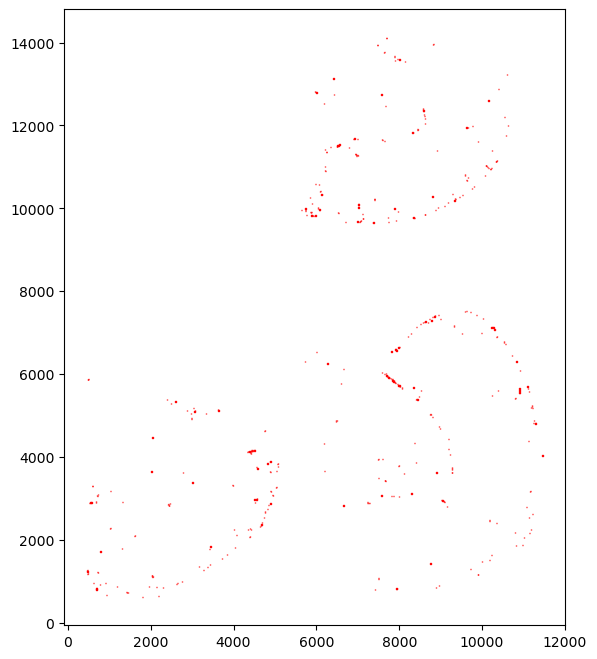

In [70]:
# SANITY CHECK: plot to make sure it worked and looks correct
# get the shapes GeoDataFrame
gdf = sdata1.shapes["CAA_noconversion"]

# plot polygons
fig, ax = plt.subplots(figsize=(8,8))
gdf.plot(ax=ax, facecolor='none', edgecolor='red')

plt.show()

### CAA and parenchymal plaques plot

/var/folders/j3/mrjbghwj6g9_vh4vwr03ppt00000gr/T/ipykernel_52548/3417287289.py:16: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/j3/mrjbghwj6g9_vh4vwr03ppt00000gr/T/ipykernel_52548/3417287289.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


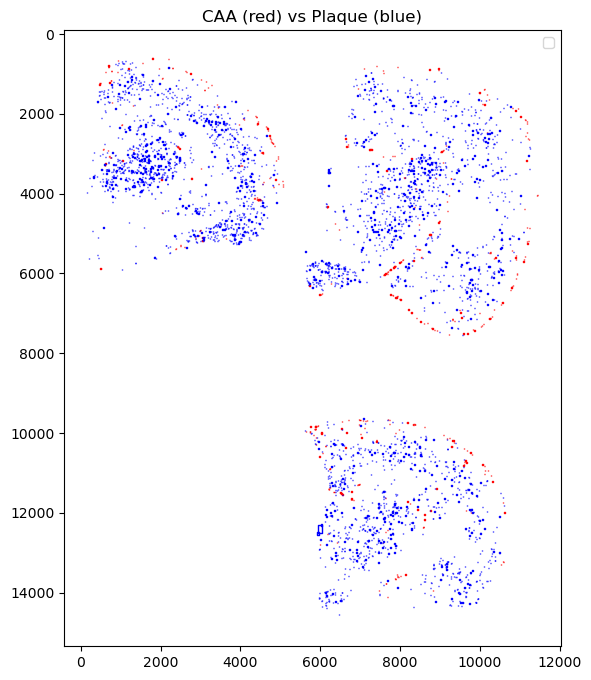

In [52]:
# visual confirmation (red = CAA and blue = parenchymal plaque, should be no overlap)

# extract plaque shapes 
gdf_plaque = sdata1.shapes["plaque"]

# slide 1
fig, ax = plt.subplots(figsize=(8, 8))

# original CAA
gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1, label="CAA")

# filtered plaques
gdf_plaque.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=1, label="Plaque")

ax.invert_yaxis()
plt.legend()
plt.title("CAA (red) vs Plaque (blue)")
plt.show()

## 10. Plot images with cells

In [32]:
sdata1.images["ThioS"]

<xarray.DataArray 'image' (c: 1, y: 112094, x: 53994)> Size: 12GB
dask.array<transpose, shape=(1, 112094, 53994), dtype=uint16, chunksize=(1, 8192, 8192), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) int64 8B 0
  * y        (y) float64 897kB 0.5 1.5 2.5 3.5 ... 1.121e+05 1.121e+05 1.121e+05
  * x        (x) float64 432kB 0.5 1.5 2.5 3.5 ... 5.399e+04 5.399e+04 5.399e+04
Attributes:
    transform:  {'global': Identity }

### Plot full slide Morph focus and ThioS images

INFO     Rasterizing image for faster rendering.                                                                   
INFO     Rasterizing image for faster rendering.                                                                   


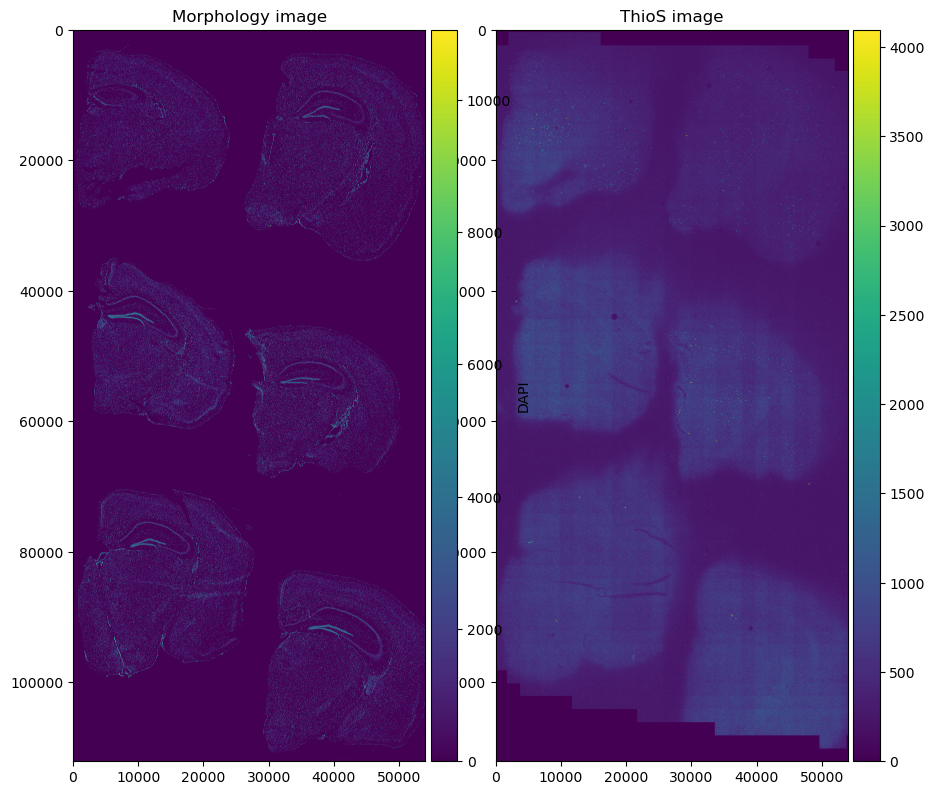

In [33]:
axes = plt.subplots(1, 2, figsize=(10, 10))[1].flatten()
sdata1.pl.render_images("morphology_focus", channel="DAPI").pl.show(ax=axes[0], title="Morphology image")
sdata1.pl.render_images("ThioS").pl.show(ax=axes[1], title="ThioS image")

INFO     Rasterizing image for faster rendering.                                                                   
INFO     Rasterizing image for faster rendering.                                                                   


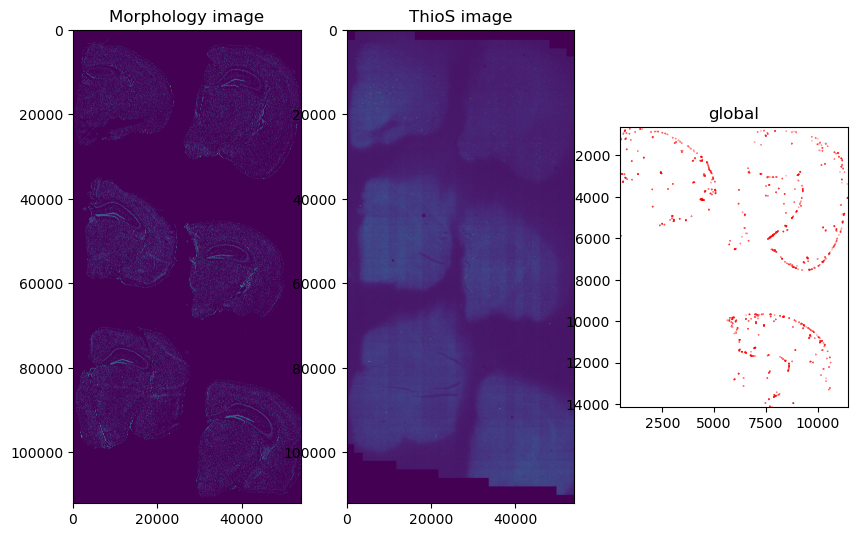

In [71]:
axes = plt.subplots(1,3, figsize = (10, 10))[1].flatten()


sdata1.pl.render_images("morphology_focus", 
                               channel="DAPI").pl.show(ax=axes[0], 
                                                       title="Morphology image", 
                                                       coordinate_systems = "global", 
                                                      colorbar = False)

sdata1.pl.render_images("ThioS").pl.show(ax=axes[1], 
                                                       title="ThioS image", 
                                                       coordinate_systems = "global", 
                                                      colorbar = False)



sdata1.pl.render_shapes(
    "CAA",
    fill_alpha=0.5,
    outline_color="red",
    outline_width=1
).pl.show(ax=axes[2], 
         coordinate_systems = "global")

INFO     Rasterizing image for faster rendering.                                                                   


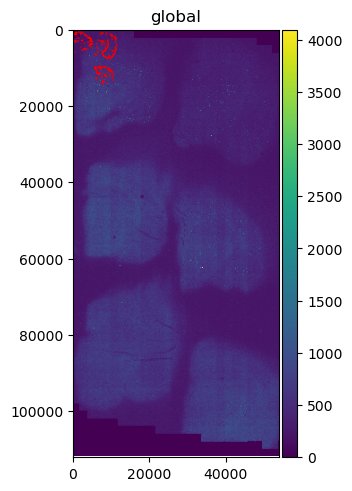

In [194]:
sdata1.pl.render_images("ThioS") \
       .pl.render_shapes(
           "CAA",
           fill_alpha=0.3,
           outline_color="red",
           outline_width=1
       ) \
       .pl.show()

In [34]:
# SANITY CHECK: check available coordinate systems 
print(sdata1.coordinate_systems)


['global']


Coordinates:
    *empty*

### Crop sdata to one sample (KK4_492 in this case) 

In [36]:
# crop images to just one sample (KK4_492)

sdata1_KK4_492_crop = sdata1.query.bounding_box(
    min_coordinate = [25_000, 0],
    max_coordinate = [55_000, 37_500],
    axes = ("x", "y"), 
    target_coordinate_system = "global" 
    )



/Users/cclu223/miniconda3/envs/scverse_env/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


In [37]:
# add CAA and plaque shapes back to obj bc bounding_box query got rid of them 

sdata1_KK4_492_crop.shapes["CAA"] = sdata1.shapes["CAA"]
sdata1_KK4_492_crop.shapes["plaque"] = sdata1.shapes["plaque"]

In [38]:
# SANITY CHECK
sdata1_KK4_492_crop

SpatialData object
├── Images
│     ├── 'ThioS': DataArray[cyx] (1, 37500, 28994)
│     └── 'morphology_focus': DataTree[cyx] (1, 37500, 28994), (1, 18750, 14497), (1, 9375, 7248), (1, 4687, 3624), (1, 2343, 1812)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (37500, 28994), (18750, 14497), (9375, 7248), (4687, 3624), (2343, 1812)
│     └── 'nucleus_labels': DataTree[yx] (37500, 28994), (18750, 14497), (9375, 7248), (4687, 3624), (2343, 1812)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'CAA': GeoDataFrame shape: (1198, 18) (2D shapes)
│     ├── 'cell_boundaries': GeoDataFrame shape: (67292, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (67292, 2) (2D shapes)
│     ├── 'nucleus_boundaries': GeoDataFrame shape: (67292, 1) (2D shapes)
│     └── 'plaque': GeoDataFrame shape: (9361, 18) (2D shapes)
└── Tables
      └── 'table': AnnData (67292, 480)
with coordinate systems:
    ▸ 'global', with elements:
       

INFO     Rasterizing image for faster rendering.                                                                   
INFO     Rasterizing image for faster rendering.                                                                   


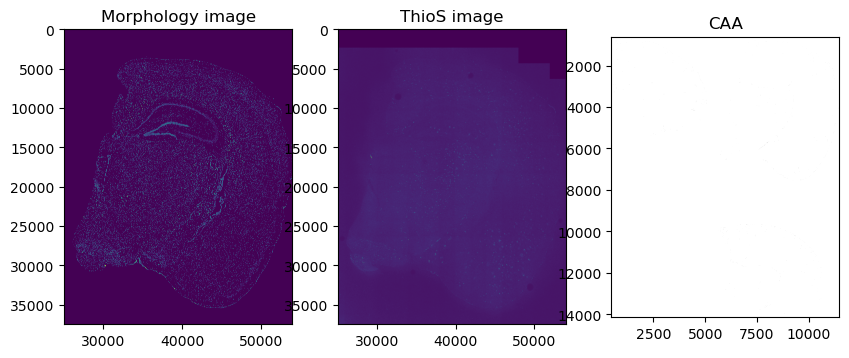

In [53]:
axes = plt.subplots(1,3, figsize = (10, 10))[1].flatten()


sdata1_KK4_492_crop.pl.render_images("morphology_focus", 
                               channel="DAPI").pl.show(ax=axes[0], 
                                                       title="Morphology image", 
                                                       coordinate_systems = "global", 
                                                      colorbar = False)

sdata1_KK4_492_crop.pl.render_images("ThioS").pl.show(ax=axes[1], 
                                                       title="ThioS image", 
                                                       coordinate_systems = "global", 
                                                      colorbar = False)



sdata1_KK4_492_crop.pl.render_labels("cell_labels").pl.show(ax=axes[2], 
                                                            title = "Cell labels", 
                                                            coordinate_systems = "global"
                                                           )

INFO     Rasterizing image for faster rendering.                                                                   
INFO     Rasterizing image for faster rendering.                                                                   


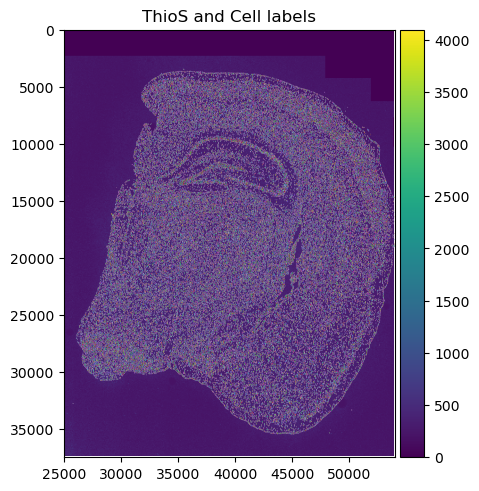

In [191]:
sdata1_KK4_492_crop.pl.render_images("ThioS").pl.render_labels("cell_labels").pl.show( 
                                                            title = "ThioS and Cell labels", 
                                                            coordinate_systems = "global"
                                                           )

### additional cropping to visualize a single CAA and cells around it 

In [42]:
sdata1_KK4_492_crop2 = sdata1.query.bounding_box(
    min_coordinate = [30_000, 2_500],
    max_coordinate = [50_000, 10_000],
    axes = ("x", "y"), 
    target_coordinate_system = "global" 
    )

/Users/cclu223/miniconda3/envs/scverse_env/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


INFO     Rasterizing image for faster rendering.                                                                   


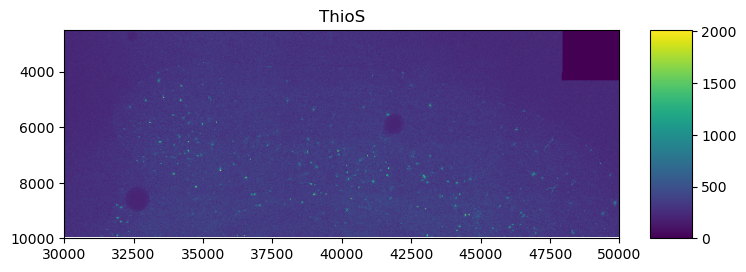

In [46]:
sdata1_KK4_492_crop2.pl.render_images("ThioS").pl.show(title = "ThioS", 
                                                        coordinate_systems = "global"
                                                        )

In [47]:
# crop

sdata1_KK4_492_crop3 = sdata1.query.bounding_box(
    min_coordinate = [45_000, 5_000],
    max_coordinate = [50_000, 10_000],
    axes = ("x", "y"), 
    target_coordinate_system = "global" 
    )

/Users/cclu223/miniconda3/envs/scverse_env/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


INFO     Rasterizing image for faster rendering.                                                                   


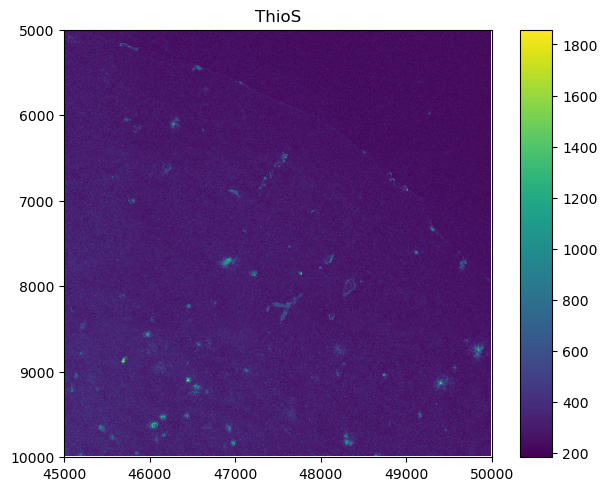

In [48]:
sdata1_KK4_492_crop3.pl.render_images("ThioS").pl.show(title = "ThioS", 
                                                        coordinate_systems = "global"
                                                        )

INFO     Rasterizing image for faster rendering.                                                                   


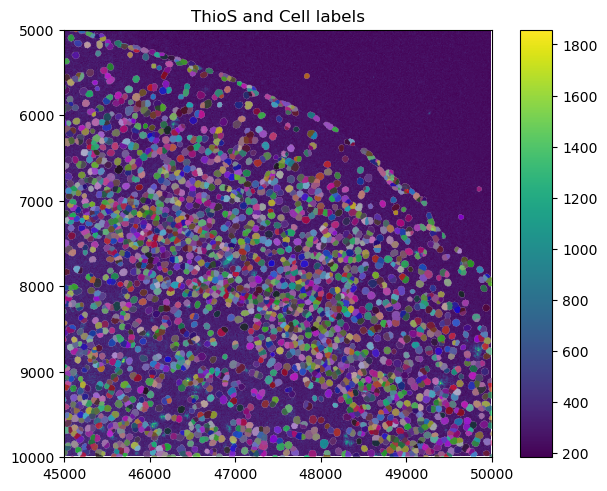

In [201]:
sdata1_KK4_492_crop3.pl.render_images("ThioS").pl.render_labels("cell_labels", color_by = "fine_celltype").pl.show( 
                                                            title = "ThioS and Cell labels", 
                                                            coordinate_systems = "global"
                                                           )

In [166]:
# crop again
sdata1_KK4_492_crop4 = sdata1.query.bounding_box(
    min_coordinate = [47_000, 7_750],
    max_coordinate = [48_000, 9_000],
    axes = ("x", "y"), 
    target_coordinate_system = "global" 
    )


/Users/cclu223/miniconda3/envs/scverse_env/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


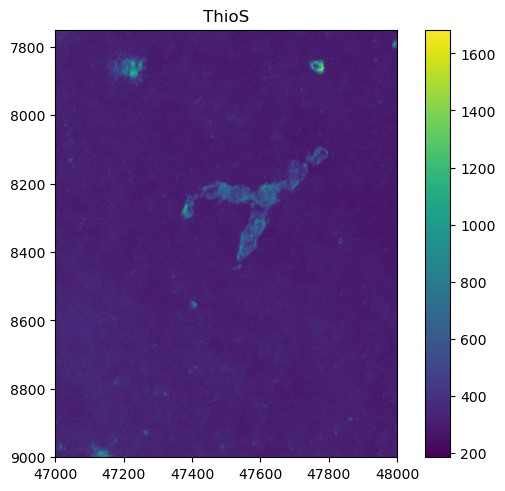

In [167]:
sdata1_KK4_492_crop4.pl.render_images("ThioS").pl.show(title = "ThioS", 
                                                        coordinate_systems = "global"
                                                        )

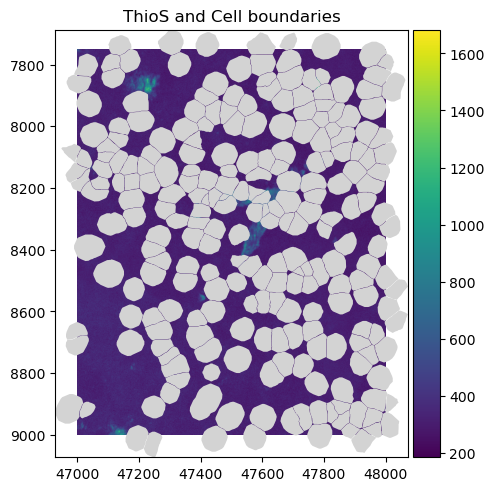

In [202]:
sdata1_KK4_492_crop4.pl.render_images("ThioS").pl.render_shapes("cell_boundaries", color_by = "fine_celltype", legend = True).pl.show( 
                                                            title = "ThioS and Cell boundaries", 
                                                            coordinate_systems = "global"
                                                           )

In [169]:
sdata1_KK4_492_crop4["table"].obs["fine_celltype"].value_counts()


fine_celltype
Glutamatergic Neuron 2     132
Oligodendrocyte             15
Astrocyte                   14
Endothelial                 13
Glutamatergic Neuron 1      11
GABAergic Neuron 2          10
GABAergic Neuron 4           4
Fibroblast                   3
OPC                          2
Pericyte                     2
VSMC                         2
ARM_microglia                1
DAM_microglia                1
Hm1_microglia                1
Hm2_microglia                1
Hm3_microglia                1
BAM                          0
CP                           0
Ependymal                    0
GABAergic Neuron 1           0
GABAergic Neuron 3           0
Glutamatergic Neuron 3       0
Glutamatergic Neuron 4       0
Glutamatergic Neuron 5       0
Gpnmb+_microglia             0
IRM_microglia                0
Il1b+_microglia              0
Proliferating_microglia      0
Spp1+_microglia              0
T Cell                       0
VLMC                         0
Name: count, dtype: int64